<a href="https://colab.research.google.com/github/isil-ada/cifar10-multi-CNN-benchmark/blob/main/notebook_03_model3_vgg11_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# YZM304 Derin Öğrenme – Proje 2
## Model 3: VGG11 (torchvision, pretrained=False) — CIFAR-10
**Optimizasyonlar (hız için):**
- ~~Resize 224×224~~ → 32×32 olduğu gibi kullanılır  
- `AdaptiveAvgPool2d(1,1)` ile feature map 1×1'e indirilir  
- FC katmanları küçültüldü (512→256→10)  
- `BATCH_SIZE=128` (önceki 64'ten artırıldı)  
> Colab: Runtime → **T4 GPU**

In [1]:
import torch, torch.nn as nn, torch.optim as optim
import torchvision, torchvision.transforms as transforms
import torchvision.models as models
import numpy as np, matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import time

torch.manual_seed(42); np.random.seed(42)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Cihaz: {DEVICE}')

Cihaz: cuda


In [2]:
# Hiperparametreler
# BATCH_SIZE=128 : resize kaldırıldı → bellek rahatladı, 128 kullanılabilir
# LR=0.0005      : derin ağ için düşük LR
# CosineAnnealing: epoch ilerledikçe LR yumuşak azalır
BATCH_SIZE, LR, EPOCHS, NUM_CLASSES = 128, 0.0005, 30, 10
CLASSES = ('plane','car','bird','cat','deer','dog','frog','horse','ship','truck')
MEAN = [0.4914, 0.4822, 0.4465]
STD  = [0.2023, 0.1994, 0.2010]

In [3]:
# ── Veri (32×32 olduğu gibi — resize YOK) ────────────────────────────────────
# Resize 224×224 kaldırıldı: hem bellek hem hesaplama yükü azaldı
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD)
])
test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD)
])

train_set = torchvision.datasets.CIFAR10('./data', train=True,  download=True, transform=train_transform)
test_set  = torchvision.datasets.CIFAR10('./data', train=False, download=True, transform=test_transform)
train_loader = torch.utils.data.DataLoader(train_set, BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
test_loader  = torch.utils.data.DataLoader(test_set,  BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
print(f'Eğitim: {len(train_set)} | Test: {len(test_set)}')

100%|██████████| 170M/170M [00:07<00:00, 21.6MB/s]


Eğitim: 50000 | Test: 10000


In [4]:
# ── Model 3: VGG11 — 32×32 CIFAR-10 için uyarlandı ──────────────────────────
# Orijinal VGG11 conv blokları KORUNDU (ödev gereksinimi karşılanıyor)
# Değişiklikler:
#   [1] avgpool → AdaptiveAvgPool2d(1,1)  : 32×32 girişte boyut uyumu sağlar
#   [2] classifier küçültüldü (512→256→10): 224 için tasarlanan büyük FC kaldırıldı
#   Bu sayede eğitim ~4-5x hızlanır

try:
    model3 = models.vgg11(weights=None)    # torchvision >= 0.13
except TypeError:
    model3 = models.vgg11(pretrained=False)

# Adaptive pooling: feature map'i her giriş boyutu için 1×1'e indirir
model3.avgpool = nn.AdaptiveAvgPool2d((1, 1))

# Yeni classifier: 512 (son conv filtre sayısı) → 256 → 10
model3.classifier = nn.Sequential(
    nn.Linear(512, 256),
    nn.ReLU(inplace=True),
    nn.Dropout(p=0.5),
    nn.Linear(256, NUM_CLASSES),
)

model3 = model3.to(DEVICE)

total_p = sum(p.numel() for p in model3.parameters() if p.requires_grad)
print(f'VGG11 (uyarlanmış) eğitilebilir parametre: {total_p:,}')
print(model3)

VGG11 (uyarlanmış) eğitilebilir parametre: 9,354,378
VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (11): Conv2d(256, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (12): ReLU(inplace=True)
    (13): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (14): ReLU(inplace=True)
    (15): MaxPool2d(kernel_size=2

In [5]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model3.parameters(), lr=LR, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

In [6]:
def train_epoch(model, loader, crit, opt, dev):
    model.train()
    ls, correct, total = 0., 0, 0
    for X, y in loader:
        X, y = X.to(dev), y.to(dev)
        opt.zero_grad(); out = model(X); loss = crit(out, y)
        loss.backward(); opt.step()
        ls += loss.item()*X.size(0)
        correct += out.argmax(1).eq(y).sum().item(); total += y.size(0)
    return ls/total, 100.*correct/total

@torch.no_grad()
def eval_epoch(model, loader, crit, dev):
    model.eval()
    ls, correct, total = 0., 0, 0
    for X, y in loader:
        X, y = X.to(dev), y.to(dev)
        out = model(X); loss = crit(out, y)
        ls += loss.item()*X.size(0)
        correct += out.argmax(1).eq(y).sum().item(); total += y.size(0)
    return ls/total, 100.*correct/total

In [7]:
hist = {'tl':[],'ta':[],'vl':[],'va':[]}
best_acc = 0.; t0 = time.time()

for ep in range(1, EPOCHS+1):
    tl, ta = train_epoch(model3, train_loader, criterion, optimizer, DEVICE)
    vl, va = eval_epoch (model3, test_loader,  criterion, DEVICE)
    scheduler.step()
    for k,v in zip(['tl','ta','vl','va'],[tl,ta,vl,va]): hist[k].append(v)
    if va > best_acc:
        best_acc = va; torch.save(model3.state_dict(), 'model3_best.pth')
    if ep % 5 == 0 or ep == 1:
        print(f'[{ep:02d}/{EPOCHS}]  Train L:{tl:.4f} A:{ta:.2f}%  |  Val L:{vl:.4f} A:{va:.2f}%')

print(f'\nSüre: {time.time()-t0:.1f}s  |  En iyi: {best_acc:.2f}%')
np.save('model3_results.npy', {'best_acc': best_acc, 'history': hist})

[01/30]  Train L:1.8011 A:30.54%  |  Val L:1.4487 A:44.40%
[05/30]  Train L:0.8090 A:72.40%  |  Val L:0.7190 A:74.88%
[10/30]  Train L:0.5141 A:82.85%  |  Val L:0.5658 A:81.15%
[15/30]  Train L:0.3601 A:87.90%  |  Val L:0.5021 A:83.57%
[20/30]  Train L:0.2356 A:92.06%  |  Val L:0.4727 A:86.08%
[25/30]  Train L:0.1591 A:94.78%  |  Val L:0.4769 A:86.63%
[30/30]  Train L:0.1250 A:95.75%  |  Val L:0.4894 A:86.89%

Süre: 734.6s  |  En iyi: 87.13%


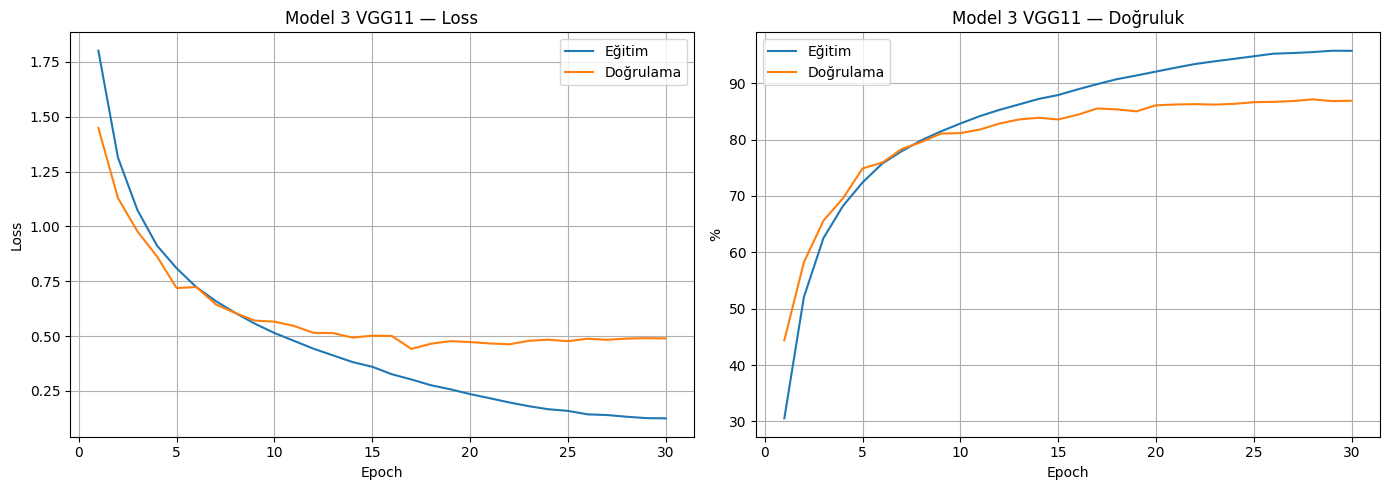

In [8]:
ep_r = range(1, EPOCHS+1)
fig, (a1, a2) = plt.subplots(1, 2, figsize=(14,5))
a1.plot(ep_r, hist['tl'], label='Eğitim');  a1.plot(ep_r, hist['vl'], label='Doğrulama')
a1.set(title='Model 3 VGG11 — Loss', xlabel='Epoch', ylabel='Loss'); a1.legend(); a1.grid()
a2.plot(ep_r, hist['ta'], label='Eğitim');  a2.plot(ep_r, hist['va'], label='Doğrulama')
a2.set(title='Model 3 VGG11 — Doğruluk', xlabel='Epoch', ylabel='%'); a2.legend(); a2.grid()
plt.tight_layout(); plt.savefig('model3_curves.png', dpi=150); plt.show()

=== Sınıflandırma Raporu — Model 3 VGG11 ===
              precision    recall  f1-score   support

       plane       0.86      0.91      0.89      1000
         car       0.94      0.94      0.94      1000
        bird       0.85      0.80      0.82      1000
         cat       0.74      0.73      0.74      1000
        deer       0.86      0.88      0.87      1000
         dog       0.80      0.80      0.80      1000
        frog       0.90      0.91      0.91      1000
       horse       0.91      0.90      0.91      1000
        ship       0.93      0.93      0.93      1000
       truck       0.92      0.91      0.92      1000

    accuracy                           0.87     10000
   macro avg       0.87      0.87      0.87     10000
weighted avg       0.87      0.87      0.87     10000



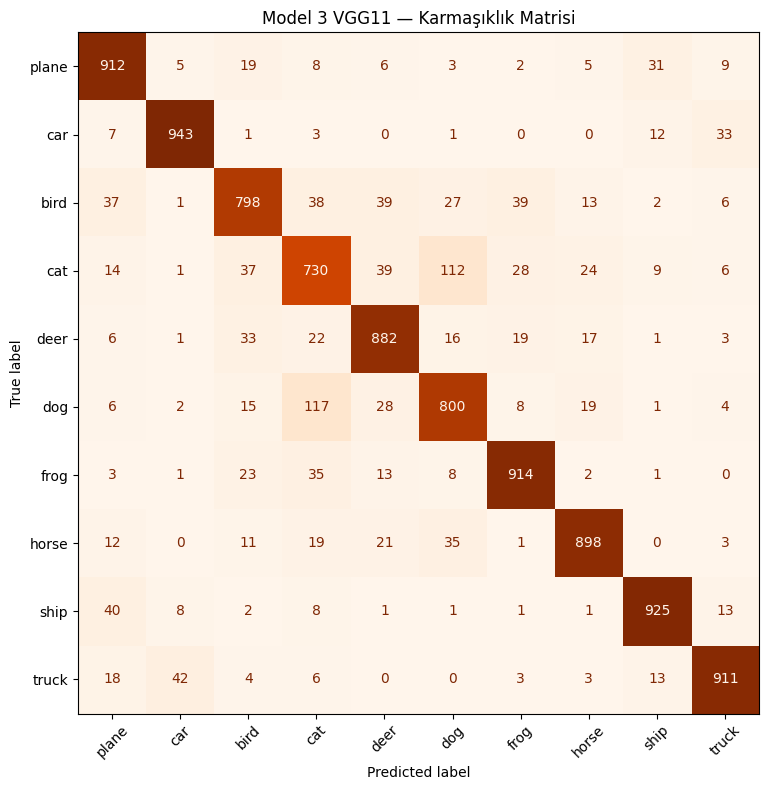


Model 3 VGG11 Nihai Test Doğruluğu: 87.13%


In [9]:
model3.load_state_dict(torch.load('model3_best.pth', map_location=DEVICE))
model3.eval()
preds, labels = [], []
with torch.no_grad():
    for X, y in test_loader:
        preds.extend(model3(X.to(DEVICE)).argmax(1).cpu().numpy())
        labels.extend(y.numpy())

print('=== Sınıflandırma Raporu — Model 3 VGG11 ===')
print(classification_report(labels, preds, target_names=CLASSES))

cm = confusion_matrix(labels, preds)
fig, ax = plt.subplots(figsize=(10,8))
ConfusionMatrixDisplay(cm, display_labels=CLASSES).plot(ax=ax,cmap='Oranges',colorbar=False,xticks_rotation=45)
ax.set_title('Model 3 VGG11 — Karmaşıklık Matrisi')
plt.tight_layout(); plt.savefig('model3_confusion.png', dpi=150); plt.show()
print(f'\nModel 3 VGG11 Nihai Test Doğruluğu: {best_acc:.2f}%')